# v5 time-evolution runtime benchmark

This notebook compares the current v5 piecewise-Liouvillian propagation with QuTiP `mesolve` for the same decay-only `^171Yb` clock-to-Rydberg model. It is intended to diagnose whether the slow v5 optimization is dominated by state time evolution, channel propagation, or exact active-channel gradients.

Default settings are deliberately small so the notebook can be executed interactively. Increase `SLOT_COUNTS` to `LONG_SLOT_COUNTS` when measuring the same scale as the production scan.

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import qutip
from scipy.linalg import expm

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "neutral_yb").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Run this notebook from inside the repository")
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from neutral_yb.config.yb171_calibration import (
    build_yb171_v5_calibrated_model,
    yb171_experimental_calibration,
    yb171_gate_time_ns_to_dimensionless,
)
from neutral_yb.models.yb171_clock_rydberg_cz_open import Yb171ClockRydbergNoiseConfig
from neutral_yb.optimization.open_system_grape import OpenSystemGRAPEConfig, OpenSystemGRAPEOptimizer

ARTIFACT_DIR = ROOT / "artifacts" / "v5" / "runtime_benchmarks" / "qutip_mesolve_vs_internal"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

OMEGA_MAX_HZ = 10e6
GATE_TIME_NS = 240.0
CLOCK_NUM_STEPS = 16
SLOT_COUNTS = (2, 4)
LONG_SLOT_COUNTS = (4, 8, 16, 32, 48, 100)
REPEATS = 1
GRADIENT_SLOT_COUNTS = (2,)
MESOLVE_RTOL = 1e-7
MESOLVE_ATOL = 1e-9

qutip.settings.core["auto_tidyup"] = False

## Shared model and control helpers

The benchmark uses the current v5 calibrated Hamiltonian with only Rydberg decay enabled. The UV controls are raw optimizer controls multiplied by the current Gaussian-edge envelope before direct state propagation, matching the v5 pulse-shape convention.

In [2]:
def build_decay_only_model(*, clock_num_steps: int = CLOCK_NUM_STEPS):
    calibration = yb171_experimental_calibration(profile="strict_literature_minimal")
    rydberg_decay = calibration.dimensionless_rate_from_lifetime(
        calibration.rydberg_lifetime_s,
        OMEGA_MAX_HZ,
    )
    model = build_yb171_v5_calibrated_model(
        include_noise=False,
        effective_rabi_hz=OMEGA_MAX_HZ,
        profile="strict_literature_minimal",
    )
    return replace(
        model,
        clock_num_steps=int(clock_num_steps),
        noise=Yb171ClockRydbergNoiseConfig(rydberg_decay_rate=rydberg_decay),
    )


def build_optimizer(num_tslots: int, *, gate_time_ns: float = GATE_TIME_NS) -> OpenSystemGRAPEOptimizer:
    model = build_decay_only_model()
    return OpenSystemGRAPEOptimizer(
        model=model,
        config=OpenSystemGRAPEConfig(
            num_tslots=int(num_tslots),
            evo_time=yb171_gate_time_ns_to_dimensionless(gate_time_ns, effective_rabi_hz=OMEGA_MAX_HZ),
            max_iter=1,
            num_restarts=1,
            seed=17,
            init_pulse_type="ZERO",
            control_smoothness_weight=0.0,
            control_curvature_weight=0.0,
            amplitude_diff_weight=0.0,
            phase_diff_weight=0.0,
            radial_amplitude_bound_weight=0.0,
            control_envelope="GAUSSIAN_EDGE",
            gaussian_edge_fraction=0.20,
            gaussian_edge_sigma_fraction=0.08,
            objective_metric="active_channel",
            benchmark_active_channel=True,
        ),
    )


def deterministic_raw_controls(optimizer: OpenSystemGRAPEOptimizer) -> tuple[np.ndarray, np.ndarray]:
    n = optimizer.config.num_tslots
    grid = np.linspace(0.0, 1.0, n, endpoint=False, dtype=np.float64)
    amplitude = optimizer.amp_bound * (0.25 + 0.55 * np.sin(np.pi * (grid + 0.15)) ** 2)
    phase = 0.15 + 1.75 * grid + 0.20 * np.sin(2.0 * np.pi * grid)
    return amplitude * np.cos(phase), amplitude * np.sin(phase)


def benchmark_state(optimizer: OpenSystemGRAPEOptimizer) -> qutip.Qobj:
    source_ket, _target_ket = optimizer.model.probe_kets(theta=0.0)[2]
    return qutip.ket2dm(source_ket)


def time_call(fn, *, repeats: int = REPEATS, warmups: int = 1) -> tuple[float, object]:
    result = None
    for _ in range(warmups):
        result = fn()
    started = time.perf_counter()
    for _ in range(repeats):
        result = fn()
    return (time.perf_counter() - started) / float(repeats), result

## Two propagation implementations

`internal_full_evolve` is the current optimizer path for one density matrix: cached fixed clock prefix, UV slot matrix exponentials, cached fixed clock suffix. `mesolve_full_evolve` sends the same full sequence to QuTiP as a piecewise-constant Hamiltonian with collapse operators.

In [3]:
def internal_uv_only_evolve(
    optimizer: OpenSystemGRAPEOptimizer,
    ctrl_x: np.ndarray,
    ctrl_y: np.ndarray,
    rho0: qutip.Qobj,
) -> qutip.Qobj:
    vector = np.asarray(rho0.full(), dtype=np.complex128).reshape(-1, order="F")
    member = optimizer.ensemble_data[0]
    for x_value, y_value in zip(ctrl_x, ctrl_y):
        l_k = member["l_d"] + float(x_value) * member["l_x"] + float(y_value) * member["l_y"]
        vector = expm(optimizer.config.dt * l_k) @ vector
    return qutip.Qobj(optimizer._vec_to_matrix(vector))


def internal_full_evolve(
    optimizer: OpenSystemGRAPEOptimizer,
    ctrl_x: np.ndarray,
    ctrl_y: np.ndarray,
    rho0: qutip.Qobj,
) -> qutip.Qobj:
    return optimizer.evolve_density_matrix(ctrl_x, ctrl_y, rho0)


def piecewise_coeff(values: np.ndarray, edges: np.ndarray):
    values = np.asarray(values, dtype=np.float64)
    edges = np.asarray(edges, dtype=np.float64)

    def coeff(t, args=None):
        index = int(np.searchsorted(edges, float(t), side="right") - 1)
        index = min(max(index, 0), values.size - 1)
        return float(values[index])

    return coeff


def mesolve_from_segments(model, rho0: qutip.Qobj, rows: list[tuple[float, float, float, float, float]]):
    durations = np.asarray([row[0] for row in rows], dtype=np.float64)
    edges = np.concatenate(([0.0], np.cumsum(durations)))
    clock_x = np.asarray([row[1] for row in rows], dtype=np.float64)
    clock_y = np.asarray([row[2] for row in rows], dtype=np.float64)
    uv_x = np.asarray([row[3] for row in rows], dtype=np.float64)
    uv_y = np.asarray([row[4] for row in rows], dtype=np.float64)

    h_d = model.drift_hamiltonian()
    h_uv_x, h_uv_y = model.lower_leg_control_hamiltonians()
    h_clock_x, h_clock_y = model.clock_control_hamiltonians()
    hamiltonian = [
        h_d,
        [h_clock_x, piecewise_coeff(clock_x, edges)],
        [h_clock_y, piecewise_coeff(clock_y, edges)],
        [h_uv_x, piecewise_coeff(uv_x, edges)],
        [h_uv_y, piecewise_coeff(uv_y, edges)],
    ]
    options = {
        "store_states": True,
        "rtol": MESOLVE_RTOL,
        "atol": MESOLVE_ATOL,
        "nsteps": 20000,
        "progress_bar": "",
    }
    result = qutip.mesolve(hamiltonian, rho0, edges, model.collapse_operators(), [], options=options)
    return result.states[-1]


def mesolve_uv_only_evolve(
    optimizer: OpenSystemGRAPEOptimizer,
    ctrl_x: np.ndarray,
    ctrl_y: np.ndarray,
    rho0: qutip.Qobj,
) -> qutip.Qobj:
    rows = [(optimizer.config.dt, 0.0, 0.0, float(x), float(y)) for x, y in zip(ctrl_x, ctrl_y)]
    return mesolve_from_segments(optimizer.model, rho0, rows)


def mesolve_full_evolve(
    optimizer: OpenSystemGRAPEOptimizer,
    ctrl_x: np.ndarray,
    ctrl_y: np.ndarray,
    rho0: qutip.Qobj,
) -> qutip.Qobj:
    segments = optimizer.model.clock_segment_controls()
    rows: list[tuple[float, float, float, float, float]] = []
    rows.extend(
        (float(segments["prefix_dt"]), float(x), float(y), 0.0, 0.0)
        for x, y in zip(segments["prefix_x"], segments["prefix_y"])
    )
    rows.extend((optimizer.config.dt, 0.0, 0.0, float(x), float(y)) for x, y in zip(ctrl_x, ctrl_y))
    rows.extend(
        (float(segments["suffix_dt"]), float(x), float(y), 0.0, 0.0)
        for x, y in zip(segments["suffix_x"], segments["suffix_y"])
    )
    return mesolve_from_segments(optimizer.model, rho0, rows)

## Run benchmark

The `active_channel_gradient_s` column times the exact GRAPE objective and gradient. This is not a `mesolve` equivalent; it is included because it is the path called by L-BFGS during the current v5 optimization.

In [4]:
rows = []

for num_tslots in SLOT_COUNTS:
    optimizer = build_optimizer(num_tslots)
    raw_x, raw_y = deterministic_raw_controls(optimizer)
    ctrl_x, ctrl_y = optimizer._apply_control_envelope(raw_x, raw_y)
    rho0 = benchmark_state(optimizer)
    variables = np.concatenate([raw_x, raw_y, np.array([0.0])])

    internal_uv_s, internal_uv_state = time_call(
        lambda: internal_uv_only_evolve(optimizer, ctrl_x, ctrl_y, rho0),
        repeats=REPEATS,
    )
    mesolve_uv_s, mesolve_uv_state = time_call(
        lambda: mesolve_uv_only_evolve(optimizer, ctrl_x, ctrl_y, rho0),
        repeats=REPEATS,
        warmups=0,
    )
    internal_full_s, internal_full_state = time_call(
        lambda: internal_full_evolve(optimizer, ctrl_x, ctrl_y, rho0),
        repeats=REPEATS,
    )
    mesolve_full_s, mesolve_full_state = time_call(
        lambda: mesolve_full_evolve(optimizer, ctrl_x, ctrl_y, rho0),
        repeats=REPEATS,
        warmups=0,
    )
    channel_s, _channel = time_call(
        lambda: optimizer.channel_superoperator(raw_x, raw_y),
        repeats=max(1, REPEATS - 1),
    )

    gradient_s = None
    if int(num_tslots) in set(int(value) for value in GRADIENT_SLOT_COUNTS):
        gradient_s, _ = time_call(
            lambda: optimizer.objective_and_gradient(variables),
            repeats=1,
        )

    rows.append(
        {
            "num_tslots": int(num_tslots),
            "uv_gate_time_ns": float(GATE_TIME_NS),
            "dt_dimensionless": float(optimizer.config.dt),
            "internal_uv_state_s": float(internal_uv_s),
            "mesolve_uv_state_s": float(mesolve_uv_s),
            "internal_full_state_s": float(internal_full_s),
            "mesolve_full_state_s": float(mesolve_full_s),
            "active_channel_superoperator_s": float(channel_s),
            "active_channel_gradient_s": None if gradient_s is None else float(gradient_s),
            "uv_state_frobenius_error": float(
                np.linalg.norm(np.asarray(internal_uv_state.full()) - np.asarray(mesolve_uv_state.full()))
            ),
            "full_state_frobenius_error": float(
                np.linalg.norm(np.asarray(internal_full_state.full()) - np.asarray(mesolve_full_state.full()))
            ),
        }
    )
    print(rows[-1])

rows

/home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


{'num_tslots': 2, 'uv_gate_time_ns': 240.0, 'dt_dimensionless': 7.539822368615505, 'internal_uv_state_s': 0.6836720520000199, 'mesolve_uv_state_s': 0.16410053699996752, 'internal_full_state_s': 0.5866870979998566, 'mesolve_full_state_s': 12.18034118699984, 'active_channel_superoperator_s': 0.6123630559998219, 'active_channel_gradient_s': 2.6121382500000436, 'uv_state_frobenius_error': 2.220446049250313e-16, 'full_state_frobenius_error': 4.375517385904325e-06}
{'num_tslots': 4, 'uv_gate_time_ns': 240.0, 'dt_dimensionless': 3.7699111843077526, 'internal_uv_state_s': 1.2454654920002213, 'mesolve_uv_state_s': 0.10841399900004944, 'internal_full_state_s': 1.7043744289999267, 'mesolve_full_state_s': 15.822406754999975, 'active_channel_superoperator_s': 1.2070889289998377, 'active_channel_gradient_s': None, 'uv_state_frobenius_error': 2.220446049250313e-16, 'full_state_frobenius_error': 0.451149336144994}


[{'num_tslots': 2,
  'uv_gate_time_ns': 240.0,
  'dt_dimensionless': 7.539822368615505,
  'internal_uv_state_s': 0.6836720520000199,
  'mesolve_uv_state_s': 0.16410053699996752,
  'internal_full_state_s': 0.5866870979998566,
  'mesolve_full_state_s': 12.18034118699984,
  'active_channel_superoperator_s': 0.6123630559998219,
  'active_channel_gradient_s': 2.6121382500000436,
  'uv_state_frobenius_error': 2.220446049250313e-16,
  'full_state_frobenius_error': 4.375517385904325e-06},
 {'num_tslots': 4,
  'uv_gate_time_ns': 240.0,
  'dt_dimensionless': 3.7699111843077526,
  'internal_uv_state_s': 1.2454654920002213,
  'mesolve_uv_state_s': 0.10841399900004944,
  'internal_full_state_s': 1.7043744289999267,
  'mesolve_full_state_s': 15.822406754999975,
  'active_channel_superoperator_s': 1.2070889289998377,
  'active_channel_gradient_s': None,
  'uv_state_frobenius_error': 2.220446049250313e-16,
  'full_state_frobenius_error': 0.451149336144994}]

## Save JSON and plot

The plot is log-scaled because the relevant conclusion is usually the relative cost of state propagation, channel propagation, and exact gradients.

saved /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/v5/runtime_benchmarks/qutip_mesolve_vs_internal/v5_qutip_mesolve_runtime_comparison.json
saved /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/v5/runtime_benchmarks/qutip_mesolve_vs_internal/v5_qutip_mesolve_runtime_comparison.png


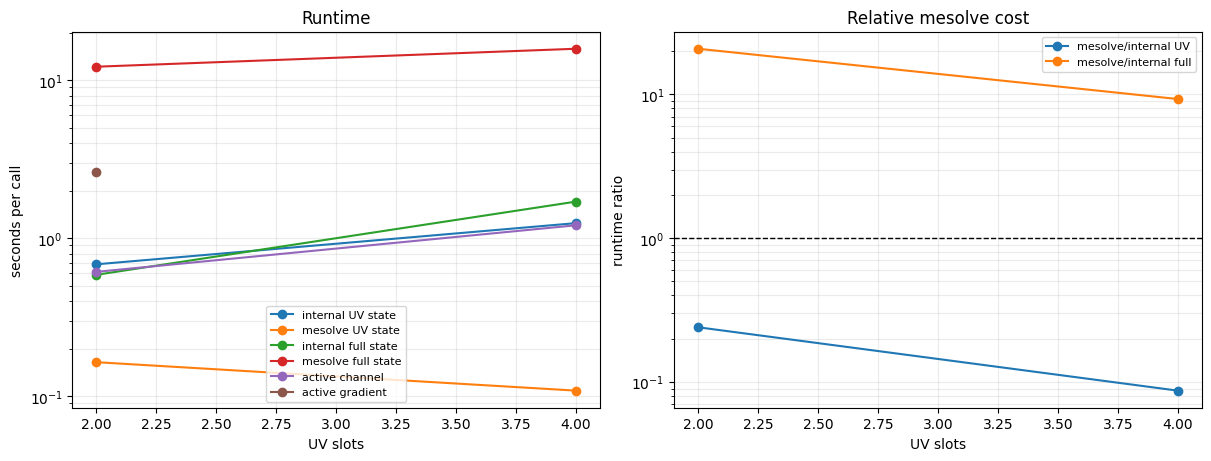

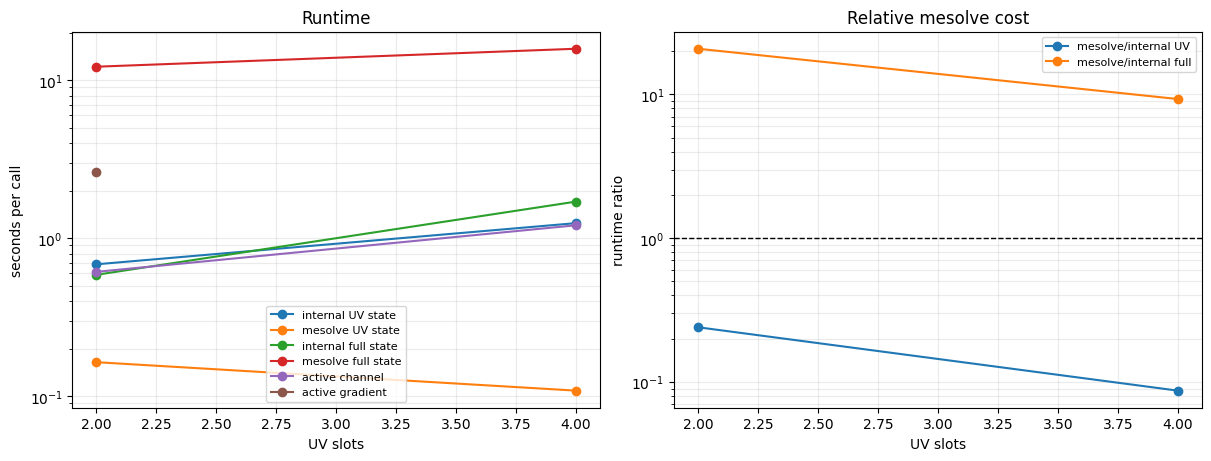

In [5]:
payload = {
    "benchmark": "v5_qutip_mesolve_vs_internal_time_evolution",
    "physical_model": {
        "model_version": "v5",
        "omega_max_hz": OMEGA_MAX_HZ,
        "uv_gate_time_ns": GATE_TIME_NS,
        "clock_num_steps": CLOCK_NUM_STEPS,
        "noise_model": "rydberg_decay_only",
        "rydberg_lifetime_s": 65e-6,
        "control_envelope": "GAUSSIAN_EDGE",
        "gaussian_edge_fraction": 0.20,
        "gaussian_edge_sigma_fraction": 0.08,
    },
    "benchmark_parameters": {
        "slot_counts": list(SLOT_COUNTS),
        "long_slot_counts_suggested": list(LONG_SLOT_COUNTS),
        "repeats": REPEATS,
        "gradient_slot_counts": list(GRADIENT_SLOT_COUNTS),
        "mesolve_rtol": MESOLVE_RTOL,
        "mesolve_atol": MESOLVE_ATOL,
    },
    "results": rows,
}

json_path = ARTIFACT_DIR / "v5_qutip_mesolve_runtime_comparison.json"
png_path = ARTIFACT_DIR / "v5_qutip_mesolve_runtime_comparison.png"
json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

slot_counts = np.asarray([row["num_tslots"] for row in rows], dtype=np.float64)
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5), constrained_layout=True)

runtime_fields = [
    ("internal_uv_state_s", "internal UV state"),
    ("mesolve_uv_state_s", "mesolve UV state"),
    ("internal_full_state_s", "internal full state"),
    ("mesolve_full_state_s", "mesolve full state"),
    ("active_channel_superoperator_s", "active channel"),
    ("active_channel_gradient_s", "active gradient"),
]
for key, label in runtime_fields:
    values = np.asarray([
        np.nan if row[key] is None else float(row[key])
        for row in rows
    ], dtype=np.float64)
    if np.isfinite(values).any():
        axes[0].plot(slot_counts, values, marker="o", label=label)

axes[0].set_yscale("log")
axes[0].set_xlabel("UV slots")
axes[0].set_ylabel("seconds per call")
axes[0].set_title("Runtime")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(fontsize=8)

ratio_uv = np.asarray([row["mesolve_uv_state_s"] / row["internal_uv_state_s"] for row in rows])
ratio_full = np.asarray([row["mesolve_full_state_s"] / row["internal_full_state_s"] for row in rows])
axes[1].plot(slot_counts, ratio_uv, marker="o", label="mesolve/internal UV")
axes[1].plot(slot_counts, ratio_full, marker="o", label="mesolve/internal full")
axes[1].axhline(1.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_yscale("log")
axes[1].set_xlabel("UV slots")
axes[1].set_ylabel("runtime ratio")
axes[1].set_title("Relative mesolve cost")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(fontsize=8)

fig.savefig(png_path, dpi=180)
print(f"saved {json_path}")
print(f"saved {png_path}")
fig